# 01 — Exploratory Data Analysis (EDA)

**Goal:** understand the Kaggle credit card fraud dataset before training any model.

We look at: data quality (missing values, duplicates), how rare fraud is, how `Amount` and `Time`
behave, which features separate fraud from normal transactions, how features correlate, and finally
we propose a **time-based** train / validation / test split for Phase 2.

Key charts are saved to `docs/figures/` for the README. Helper functions live in `ml/eda_utils.py`
(and are unit-tested in `tests/test_eda_utils.py`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.eda_utils import (
    load_data, duplicate_summary, class_balance, add_hour_of_day,
    fraud_rate_by_hour, rank_features, time_split_boundaries,
)

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {0: "#4C72B0", 1: "#DD4444"}   # normal = blue, fraud = red
LABELS = {0: "Normal", 1: "Fraud"}
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def save(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
    print(f"saved docs/figures/{name}")

## 1. Overview: shape, types, missing values, duplicates

In [2]:
df = load_data()
print("shape:", df.shape)
df.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
print(df.dtypes.value_counts())
print("\nmissing values in whole table:", int(df.isna().sum().sum()))

float64    30
int64       1
Name: count, dtype: int64

missing values in whole table: 0


In [4]:
dup = duplicate_summary(df)
dup

{'duplicate_rows': 1081,
 'duplicate_fraud_rows': 19,
 'duplicate_pct': 0.379555277784605}

**Reading this:** a *duplicate row* is a transaction whose every column (including `Time` and `Amount`)
matches an earlier one. We count only the extra copies. Duplicates are a small share of data, but if
the same row lands in both train and test it inflates scores — something to keep in mind in Phase 2.

## 2. Class imbalance

Fraud (`Class = 1`) is extremely rare. This is the single most important fact about the dataset.

In [5]:
cb = class_balance(df)
cb.index = cb.index.map(LABELS)
display(cb)
print(f"A model that always says 'normal' would be {cb.loc['Normal','pct']:.2f}% accurate — and catch zero fraud.")

,count,pct
Class,,
Normal,284315,99.8273
Fraud,492,0.1727


A model that always says 'normal' would be 99.83% accurate — and catch zero fraud.


saved docs/figures/class_balance.png


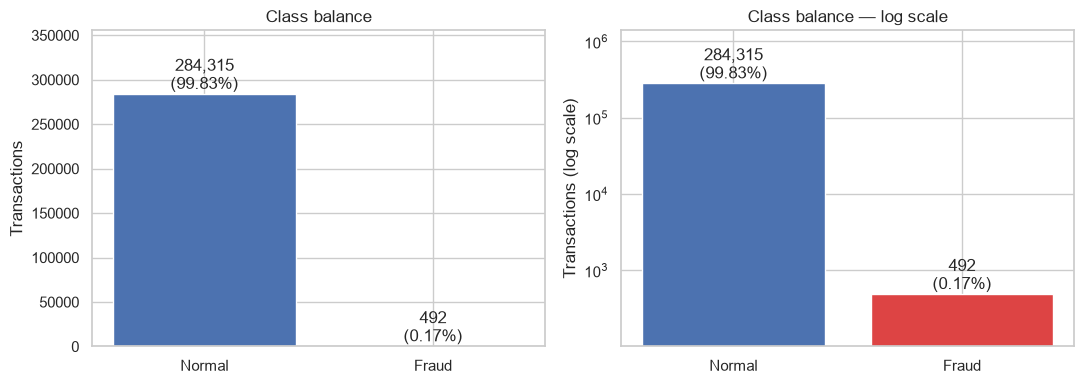

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, log in zip(axes, [False, True]):
    ax.bar(cb.index, cb["count"], color=[COLORS[0], COLORS[1]])
    for i, (c, p) in enumerate(zip(cb["count"], cb["pct"])):
        ax.text(i, c, f"{c:,}\n({p:.2f}%)", ha="center", va="bottom")
    ax.set_yscale("log" if log else "linear")
    ax.set_ylabel("Transactions" + (" (log scale)" if log else ""))
    ax.set_title("Class balance" + (" — log scale" if log else ""))
    ax.margins(y=0.25)
fig.tight_layout()
save(fig, "class_balance.png")
plt.show()

## 3. Amount

How much money is involved in normal vs fraudulent transactions? Amounts are very skewed (many small,
a few huge), so we plot `log(1 + Amount)`.

In [7]:
amount_stats = df.groupby("Class")["Amount"].describe()
amount_stats.index = amount_stats.index.map(LABELS)
amount_stats

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Normal,"284,315.0000",88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,"25,691.1600"
Fraud,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,"2,125.8700"


In [8]:
print("Share of transactions with Amount == 0:")
print(df.assign(zero=df["Amount"].eq(0)).groupby("Class")["zero"].mean().rename(LABELS) * 100)
print(f"\nTotal fraud amount: ${df.loc[df.Class == 1, 'Amount'].sum():,.2f}")

Share of transactions with Amount == 0:
Class
Normal   0.6324
Fraud    5.4878
Name: zero, dtype: float64

Total fraud amount: $60,127.97


saved docs/figures/amount_distribution.png


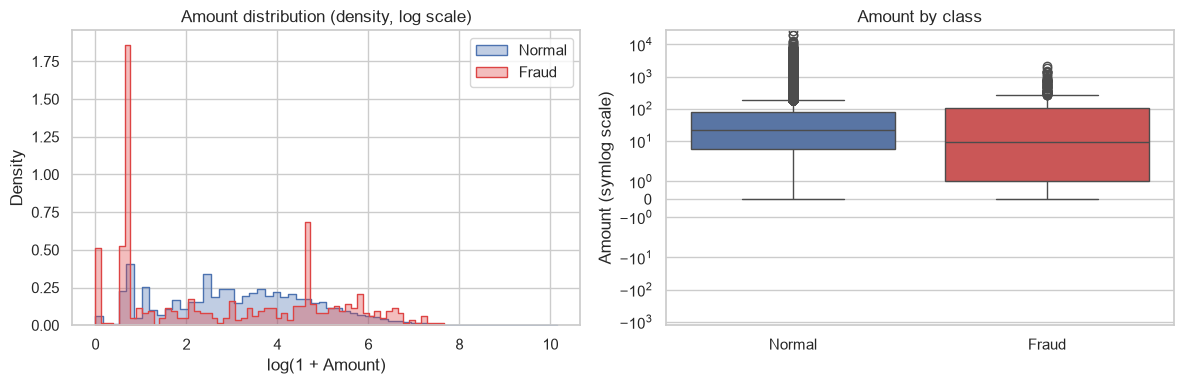

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
log_amt = np.log1p(df["Amount"])
for cls in [0, 1]:
    sns.histplot(log_amt[df.Class == cls], bins=60, stat="density", element="step",
                 fill=True, alpha=0.35, color=COLORS[cls], label=LABELS[cls], ax=axes[0])
axes[0].set_xlabel("log(1 + Amount)")
axes[0].set_title("Amount distribution (density, log scale)")
axes[0].legend()

sns.boxplot(x=df["Class"].map(LABELS), y=df["Amount"], hue=df["Class"].map(LABELS),
            palette={"Normal": COLORS[0], "Fraud": COLORS[1]}, ax=axes[1], legend=False)
axes[1].set_yscale("symlog")
axes[1].set_xlabel("")
axes[1].set_ylabel("Amount (symlog scale)")
axes[1].set_title("Amount by class")
fig.tight_layout()
save(fig, "amount_distribution.png")
plt.show()

## 4. Time

`Time` = seconds since the first transaction in the file; the data covers ~2 days (172,800 s).
We turn it into an **hour of day** (0–23, relative to the start of the data — the dataset does not
say what clock time hour 0 is, but the volume pattern below strongly suggests it is around midnight).

In [10]:
df = add_hour_of_day(df)
by_hour = fraud_rate_by_hour(df)
by_hour

,transactions,frauds,fraud_rate_pct
hour,,,
0,7695,6,0.0780
1,4220,10,0.2370
2,3328,57,1.7127
3,3492,17,0.4868
4,2209,23,1.0412
5,2990,11,0.3679
6,4101,9,0.2195
7,7243,23,0.3175
8,10276,9,0.0876


saved docs/figures/fraud_rate_by_hour.png


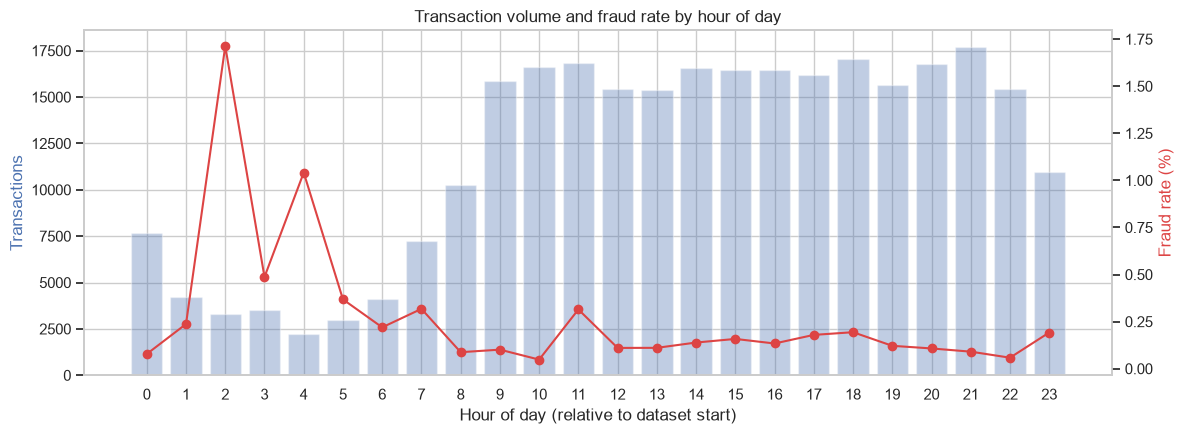

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(by_hour.index, by_hour["transactions"], color=COLORS[0], alpha=0.35, label="Transactions")
ax1.set_xlabel("Hour of day (relative to dataset start)")
ax1.set_ylabel("Transactions", color=COLORS[0])
ax1.set_xticks(range(24))
ax2 = ax1.twinx()
ax2.plot(by_hour.index, by_hour["fraud_rate_pct"], color=COLORS[1], marker="o", label="Fraud rate")
ax2.set_ylabel("Fraud rate (%)", color=COLORS[1])
ax2.grid(False)
ax1.set_title("Transaction volume and fraud rate by hour of day")
fig.tight_layout()
save(fig, "fraud_rate_by_hour.png")
plt.show()

saved docs/figures/transactions_over_time.png


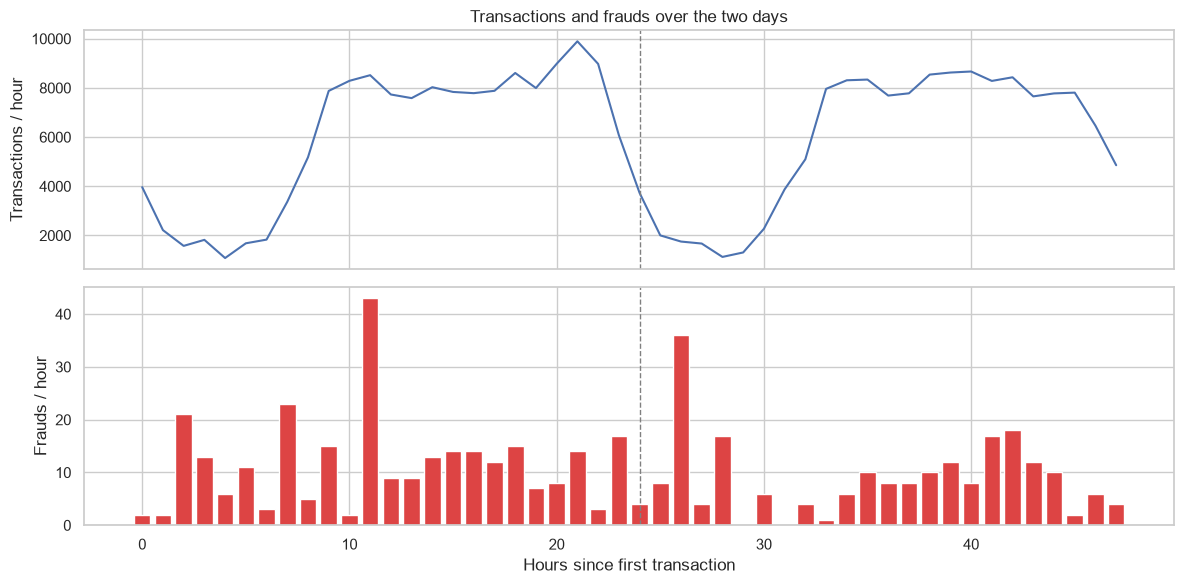

In [12]:
hour_abs = (df["Time"] // 3600).astype(int)   # 0..47 across the two days
timeline = df.groupby(hour_abs)["Class"].agg(transactions="count", frauds="sum")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(timeline.index, timeline["transactions"], color=COLORS[0])
axes[0].set_ylabel("Transactions / hour")
axes[0].set_title("Transactions and frauds over the two days")
axes[1].bar(timeline.index, timeline["frauds"], color=COLORS[1])
axes[1].set_ylabel("Frauds / hour")
axes[1].set_xlabel("Hours since first transaction")
for ax in axes:
    ax.axvline(24, color="grey", ls="--", lw=1)
fig.tight_layout()
save(fig, "transactions_over_time.png")
plt.show()

**Reading this:** volume follows a clear day/night cycle (two "days" with a dip at night), while fraud
does not drop as much at night — so the *fraud rate* is highest in the quiet hours. Fraud also comes
in bursts (some hours have many more frauds than others), which is why the split must respect time.

## 5. Which features separate fraud from normal?

We rank every feature two ways:
- **Standardized mean difference** — how far apart the fraud and normal averages are, in units of
  standard deviation (bigger = more different).
- **Mutual information** — how much knowing the feature reduces uncertainty about the class; it also
  catches non-linear relationships.

In [13]:
features = df.drop(columns=["hour"])
ranking = rank_features(features)
ranking

,std_mean_diff,mutual_info
V17,7.8619,0.0083
V14,7.2854,0.0081
V12,6.2752,0.0076
V10,5.2227,0.0075
V11,3.7295,0.0068
V16,4.7328,0.0061
V4,3.2135,0.0050
V3,4.6466,0.0050
V18,2.6846,0.0043
V9,2.3535,0.0043


saved docs/figures/feature_ranking.png


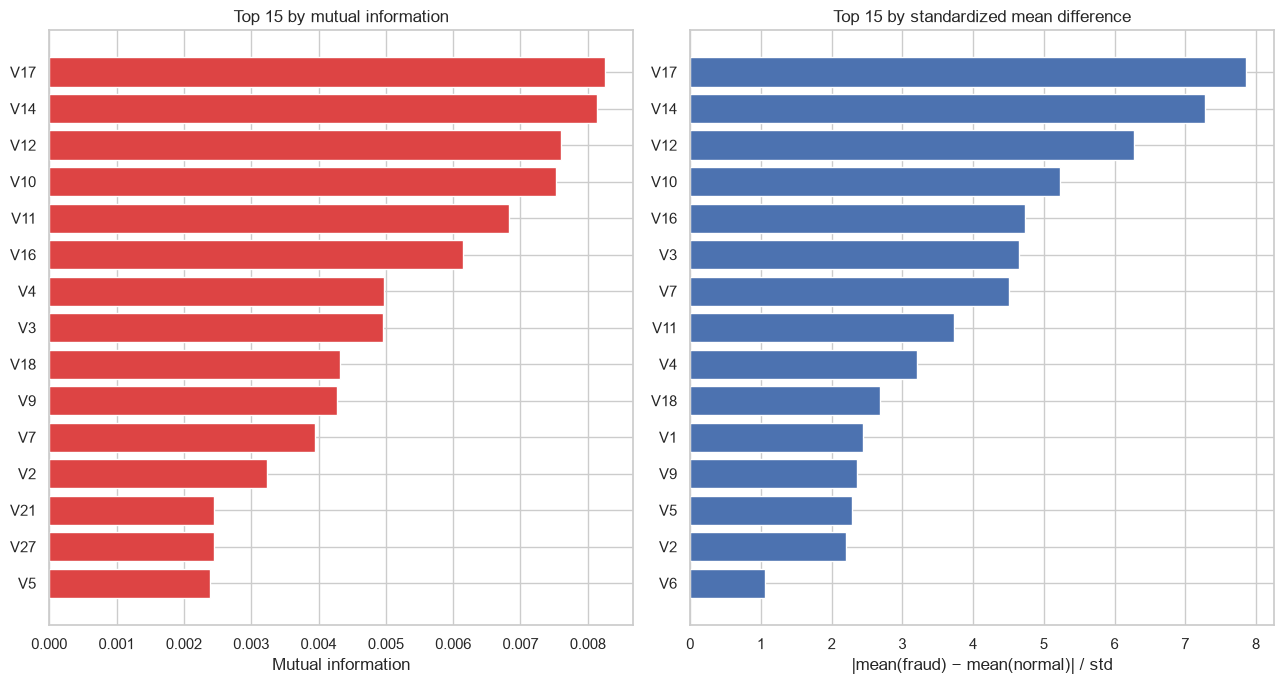

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=False)
top15 = ranking.head(15)
axes[0].barh(top15.index[::-1], top15["mutual_info"][::-1], color=COLORS[1])
axes[0].set_title("Top 15 by mutual information")
axes[0].set_xlabel("Mutual information")
by_diff = ranking.sort_values("std_mean_diff", ascending=False).head(15)
axes[1].barh(by_diff.index[::-1], by_diff["std_mean_diff"][::-1], color=COLORS[0])
axes[1].set_title("Top 15 by standardized mean difference")
axes[1].set_xlabel("|mean(fraud) − mean(normal)| / std")
fig.tight_layout()
save(fig, "feature_ranking.png")
plt.show()

saved docs/figures/top_feature_kdes.png


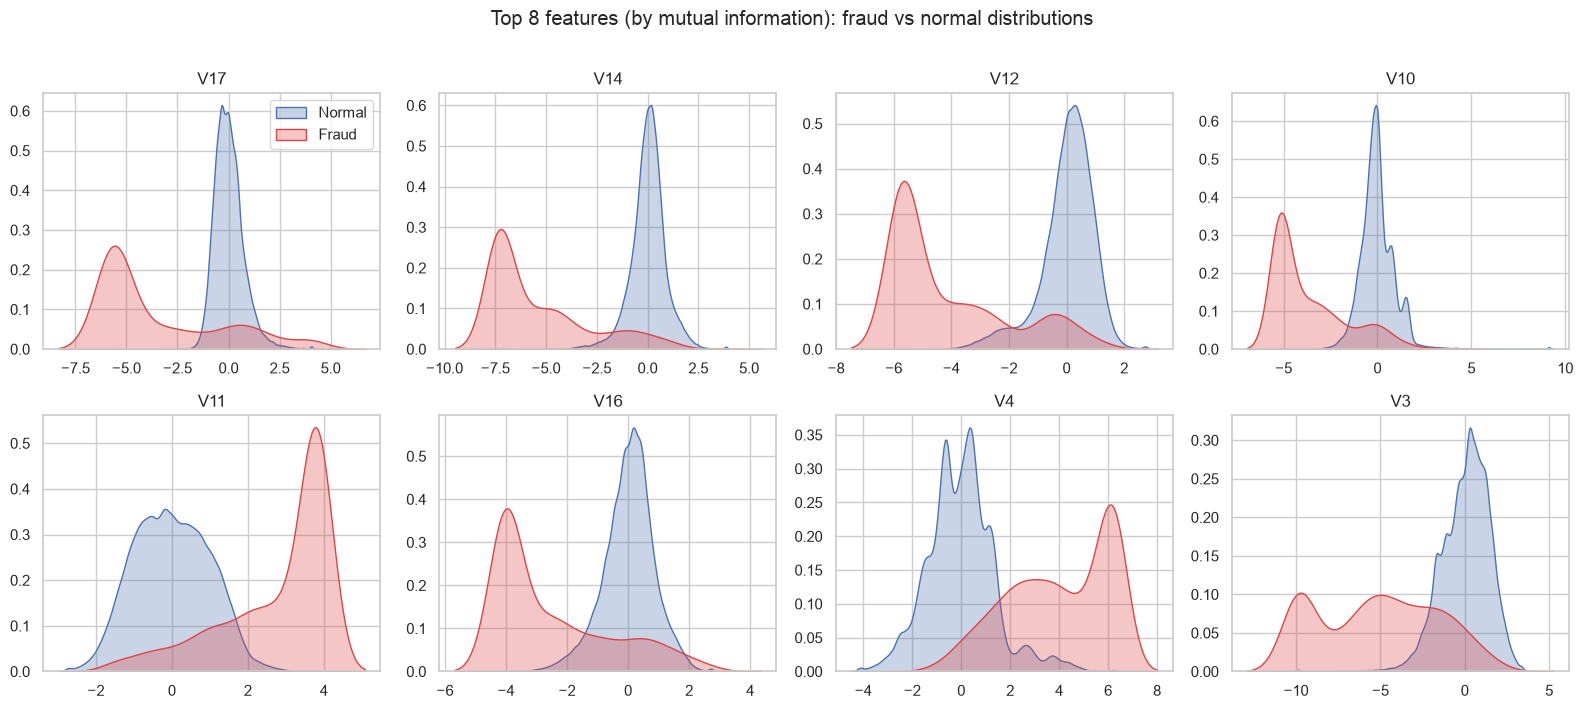

In [15]:
top8 = ranking.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, top8):
    lo, hi = df[col].quantile([0.001, 0.999])
    for cls in [0, 1]:
        vals = df.loc[df.Class == cls, col].clip(lo, hi)
        sns.kdeplot(vals, ax=ax, color=COLORS[cls], fill=True, alpha=0.3,
                    label=LABELS[cls], warn_singular=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes.flat[0].legend()
fig.suptitle("Top 8 features (by mutual information): fraud vs normal distributions", y=1.01)
fig.tight_layout()
save(fig, "top_feature_kdes.png")
plt.show()

**Reading this:** for the top features the red (fraud) curve sits clearly apart from the blue (normal)
curve — these are the signals a model will lean on. Each class's curve is normalized on its own, so
the tiny fraud class is visible. Values are clipped to the 0.1–99.9th percentile for readability.

## 6. Correlation

`V1`–`V28` come from PCA, which by construction produces **uncorrelated** components — so on the full
data the heatmap is mostly blank. On a **balanced** sample (all frauds + an equal number of random
normal transactions) the fraud-related structure becomes visible. The balanced sample is for
*looking only*; it is not used for training.

saved docs/figures/correlation_heatmap.png


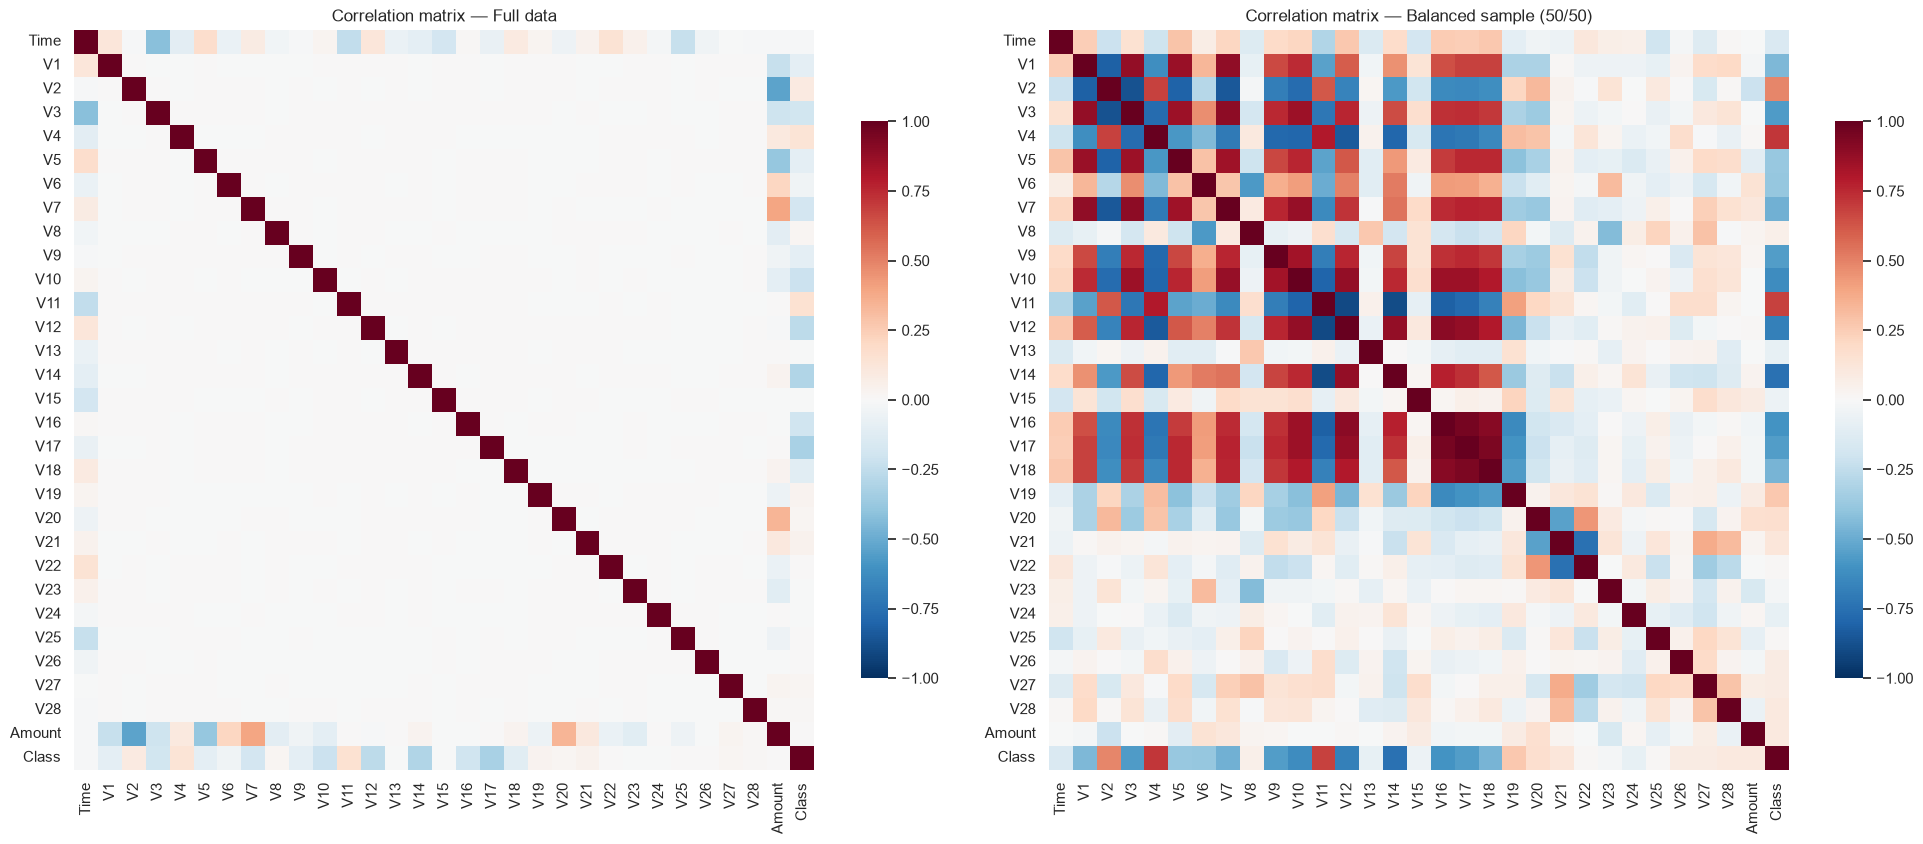

In [16]:
balanced = pd.concat([
    features[features.Class == 1],
    features[features.Class == 0].sample(n=int(features.Class.sum()), random_state=42),
])
fig, axes = plt.subplots(1, 2, figsize=(20, 8.5))
for ax, data, title in [(axes[0], features, "Full data"), (axes[1], balanced, "Balanced sample (50/50)")]:
    sns.heatmap(data.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(f"Correlation matrix — {title}")
fig.tight_layout()
save(fig, "correlation_heatmap.png")
plt.show()

saved docs/figures/correlation_with_class.png


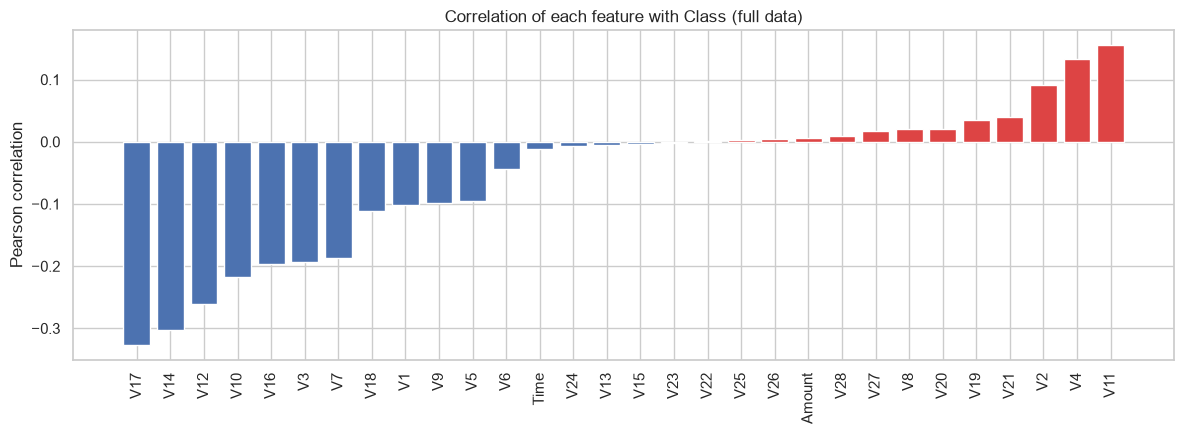

V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V11    0.1549
V4     0.1334
V18   -0.1115
Name: Class, dtype: float64

In [17]:
corr_class = features.corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(corr_class.index, corr_class.values,
       color=[COLORS[1] if v > 0 else COLORS[0] for v in corr_class.values])
ax.set_title("Correlation of each feature with Class (full data)")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
save(fig, "correlation_with_class.png")
plt.show()
corr_class.reindex(corr_class.abs().sort_values(ascending=False).index).head(10)

**Reading this:** no single feature has a large linear correlation with `Class` on the full data —
because fraud is so rare, even strong signals give small Pearson values. The ranking agrees with
section 5 on *which* features matter. Some `V` features are negatively related (low values = fraud),
others positively.

## 7. Proposed time-based split (70 / 15 / 15)

We sort by `Time` and cut by row count: the first 70% of transactions train the model, the next 15%
tune it (validation — threshold and model choice), and the last 15% are the untouched test set (and
the stream the simulator will replay). A random split would let the model "see the future".

In [18]:
splits = time_split_boundaries(features)
splits["start_hour"] = splits["start_time"] / 3600
splits["end_hour"] = splits["end_time"] / 3600
display(splits)
print("frauds across splits:", splits["frauds"].sum(), "| rows:", splits["rows"].sum())

,start_time,end_time,rows,frauds,fraud_pct,start_hour,end_hour
split,,,,,,,
train,0.0000,"132,928.0000",199364,384,0.1926,0.0000,36.9244
validation,"132,929.0000","151,328.0000",42722,56,0.1311,36.9247,42.0356
test,"151,329.0000","172,792.0000",42721,52,0.1217,42.0358,47.9978


frauds across splits: 492 | rows: 284807


saved docs/figures/time_split.png


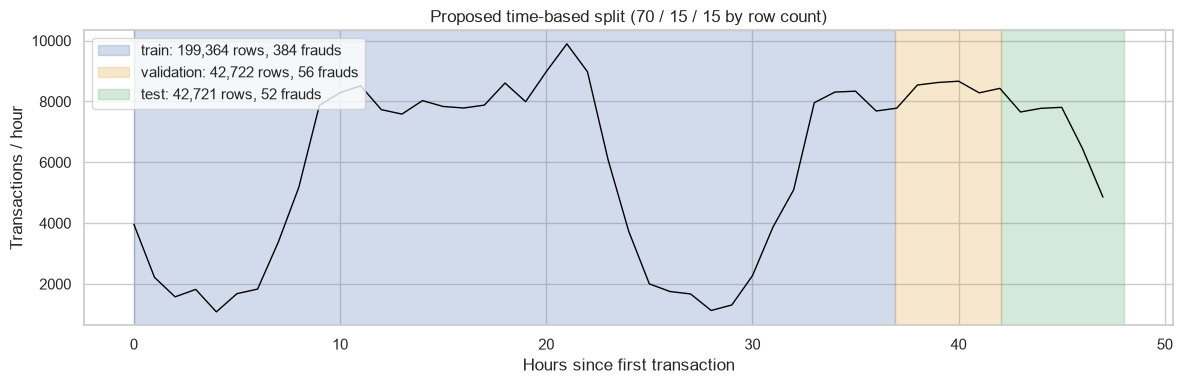

In [19]:
split_colors = {"train": "#4C72B0", "validation": "#E1A03A", "test": "#55A868"}
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(timeline.index, timeline["transactions"], color="black", lw=1)
for name, row in splits.iterrows():
    ax.axvspan(row.start_hour, row.end_hour, color=split_colors[name], alpha=0.25,
               label=f"{name}: {int(row.rows):,} rows, {int(row.frauds)} frauds")
ax.set_xlabel("Hours since first transaction")
ax.set_ylabel("Transactions / hour")
ax.set_title("Proposed time-based split (70 / 15 / 15 by row count)")
ax.legend(loc="upper left")
fig.tight_layout()
save(fig, "time_split.png")
plt.show()

## 8. Key findings

Full write-up with chart links: [`docs/eda_findings.md`](../../docs/eda_findings.md).


1. **The data is clean.** No missing values, and every column is numeric (30 float, 1 int `Class`). `V1`–`V28` are already scaled PCA components; only `Time` and `Amount` are raw.
   → *Phase 2:* no imputation needed. Scale only `Amount` (and any time feature we derive), and fit the scaler on the training split only.

2. **There are 1,081 exact duplicate rows (0.38%), 19 of them fraud.** Each duplicate has the same `Time` as its original, and the split keeps equal timestamps together, so a duplicate never ends up in a different split from its original (no train→test leakage).
   → *Phase 2:* keep duplicates in validation/test, since repeats happen in real traffic. Optionally drop them from train and check whether metrics change.

3. **Fraud is extremely rare: 492 of 284,807 transactions (0.173%).** A model that always answers "normal" gets 99.83% accuracy and catches no fraud at all. 
   → *Phase 2:* never report accuracy. Use PR-AUC, precision/recall/F1, recall at 90% precision, and cost saved. Compare class weights, SMOTE and undersampling, applied to the training split only.

4. **Fraud amounts look different from normal ones.** The median fraud is smaller ($9.25 vs $22.00) but the average is larger ($122 vs $88). 5.5% of frauds are $0.00 (vs 0.6% of normal transactions), which looks like "card testing". The largest fraud is $2,126 and total fraud is $60,128. 
   → *Phase 2:* `Amount` is weak on its own (22nd of 30 by mutual information) but it is needed for the **cost-saved** metric. It is heavily skewed, so use `log1p` or robust scaling for Logistic Regression (tree models don't need scaling). A `$0` rule is a good candidate for the Phase 3 rules layer.

5. **Fraud is concentrated at night.** Volume drops sharply in hours 1–7 (relative to the start of the data, which looks like midnight). In those hours the fraud rate jumps: 1.71% in hour 2 and 1.04% in hour 4, against about 0.1–0.2% during the day. 
   → *Phase 2:* add an `hour_of_day` feature (or sine/cosine of it). Don't feed raw `Time` to the model, because it only says where a row sits in a 2-day window and won't generalize.

6. **Fraud arrives in bursts.** Some single hours have 50+ frauds while their neighbours have fewer than 10 (see the timeline). 
   → *Phase 2:* this is why the split must follow time. A random split would put pieces of the same fraud burst in both train and test and make the scores look better than they are.

7. **A handful of features separate fraud very strongly.** The top features are V17, V14, V12, V10, V11, V16, V4 and V3. For V17 the fraud and normal averages are 7.9 standard deviations apart. Most of them are *lower* for fraud; V11 and V4 are *higher*.  
   → *Phase 2:* we expect even simple models to do well. When SHAP is ready, these features should be at the top of its rankings, which gives us a quick sanity check.

8. **Several features carry almost no signal.** V13, V15, V22, V23, V24, V25 and V26 have near-zero mutual information and near-identical averages for both classes.
   → *Phase 2:* candidates to drop for Logistic Regression if it helps. Keep them for tree models and let the validation set decide, rather than pruning by hand.

9. **On the full data the features are uncorrelated with each other, and only weakly correlated with `Class`.** This is expected from PCA. The strongest correlation with `Class` is V17 at −0.33. On a balanced 50/50 sample, strong shared patterns among the fraud-related features show up.  
   → *Phase 2:* multicollinearity is not a concern on the real data. Pearson correlation understates signal for a rare class, so rank features with mutual information or model importance instead.

10. **Proposed 70/15/15 time split:** train = 199,364 rows / 384 frauds (0.19%), validation = 42,722 / 56 (0.13%), test = 42,721 / 52 (0.12%). The cut points are at `Time` 132,929 s and 151,329 s. 
    → *Phase 2:* use these boundaries. Three caveats:
    - (a) The fraud rate is lower in later periods, so validation and test scores will probably look worse than cross-validated training scores. That is the honest result.
    - (b) With only about 52–56 frauds, each one moves recall by about 2 points. Report test metrics with that in mind (bootstrap confidence intervals would help).
    - (c) Validation and test cover only the afternoon and evening of day 2, with **no night hours**. The night-time fraud spike in finding 5 is learned in training but barely tested.